# 05 - Asociacion: canasta de mercado

Objetivo: descubrir reglas de asociacion en boletas de AndesMarket para proponer promociones cruzadas y acciones de merchandising.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'data' / 'processed'
IMG = ROOT / 'informe' / 'img'
IMG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')

## 1. Carga de datos

La unidad de analisis es la boleta (`id_venta`). Cada transaccion contiene las categorias compradas dentro de esa boleta. Se trabaja a nivel categoria porque es mas interpretable para promociones cruzadas en Power BI.

In [2]:
fact = pd.read_csv(DATA / 'fact_ventas.csv', sep=';')
productos = pd.read_csv(DATA / 'dim_producto.csv', sep=';')

df = fact.merge(productos[['id_producto', 'nombre', 'categoria']], on='id_producto', how='left')
df.head()

,id_venta,fecha,id_cliente,id_producto,id_tienda,id_promocion,cantidad,precio_unitario,descuento,importe,costo_total,margen,nombre,categoria
0,V0027569,2025-08-28,C01502,P0162,T015,PR000,1,37.62,0.0,37.62,26.29,11.33,Aceite Norte 162,Abarrotes
1,V0018420,2025-09-27,C00706,P0362,T002,PR000,1,5.62,0.0,5.62,3.71,1.91,Lavavajilla Ayni 362,Limpieza
2,V0010328,2024-12-12,C04281,P0113,T014,PR000,1,48.35,0.0,48.35,40.07,8.28,Conservas Norte 113,Abarrotes
3,V0018216,2025-12-29,C01722,P0151,T009,PR000,1,12.68,0.0,12.68,7.54,5.14,Arroz Kantu 151,Abarrotes
4,V0019843,2024-03-10,C02654,P0186,T011,PR000,1,11.86,0.0,11.86,6.79,5.07,Keke Inti 186,Panaderia


## 2. Preparacion de transacciones

Se agrupan categorias por boleta y se conservan boletas con al menos dos categorias distintas, porque las reglas de asociacion requieren coocurrencia.

In [3]:
transacciones = (
    df.groupby('id_venta')['categoria']
      .apply(lambda s: sorted(set(s.dropna())))
      .reset_index(name='items')
)
transacciones['n_items'] = transacciones['items'].apply(len)
transacciones_validas = transacciones[transacciones['n_items'] >= 2].copy()

resumen_transacciones = pd.DataFrame({
    'metrica': ['boletas_totales', 'boletas_con_2_o_mas_categorias', 'items_promedio_boleta_valida'],
    'valor': [len(transacciones), len(transacciones_validas), transacciones_validas['n_items'].mean()],
})
resumen_transacciones

,metrica,valor
0,boletas_totales,32712.0
1,boletas_con_2_o_mas_categorias,26690.0
2,items_promedio_boleta_valida,2.0


## 3. One-hot encoding y itemsets frecuentes

Se codifican las canastas en una matriz booleana y se aplica Apriori. El soporte minimo se fija en 1% para capturar reglas accionables sin generar ruido excesivo.

In [4]:
te = TransactionEncoder()
matriz = te.fit_transform(transacciones_validas['items'])
basket = pd.DataFrame(matriz, columns=te.columns_)

itemsets = apriori(basket, min_support=0.01, use_colnames=True)
itemsets['itemsets_txt'] = itemsets['itemsets'].apply(lambda x: ', '.join(sorted(x)))
itemsets['n_items'] = itemsets['itemsets'].apply(len)
itemsets = itemsets.sort_values(['n_items', 'support'], ascending=[True, False])
itemsets.head(15)

,support,itemsets,itemsets_txt,n_items
1,0.347209,frozenset({Bebidas}),Bebidas,1
9,0.343050,frozenset({Snacks}),Snacks,1
6,0.238741,frozenset({Lacteos}),Lacteos,1
7,0.232746,frozenset({Limpieza}),Limpieza,1
8,0.231135,frozenset({Panaderia}),Panaderia,1
0,0.220457,frozenset({Abarrotes}),Abarrotes,1
2,0.182128,frozenset({Carnes}),Carnes,1
3,0.173323,frozenset({Congelados}),Congelados,1
5,0.017048,frozenset({Frutas y verduras}),Frutas y verduras,1
4,0.014163,frozenset({Cuidado personal}),Cuidado personal,1


## 4. Reglas de asociacion

Se calculan soporte, confianza y lift. Se conservan reglas con `lift > 1`, porque indican asociacion positiva entre antecedente y consecuente.

In [5]:
reglas = association_rules(itemsets, metric='confidence', min_threshold=0.10)
reglas = reglas[reglas['lift'] > 1].copy()
reglas['antecedente'] = reglas['antecedents'].apply(lambda x: ', '.join(sorted(x)))
reglas['consecuente'] = reglas['consequents'].apply(lambda x: ', '.join(sorted(x)))
reglas['regla'] = reglas['antecedente'] + ' -> ' + reglas['consecuente']
reglas = reglas.sort_values(['lift', 'confidence', 'support'], ascending=False)

columnas_reglas = ['regla', 'antecedente', 'consecuente', 'support', 'confidence', 'lift']
reglas[columnas_reglas].head(10)

,regla,antecedente,consecuente,support,confidence,lift
7,Congelados -> Carnes,Congelados,Carnes,0.163245,0.941850,5.171361
6,Carnes -> Congelados,Carnes,Congelados,0.163245,0.896318,5.171361
3,Panaderia -> Lacteos,Panaderia,Lacteos,0.223679,0.967742,4.053520
2,Lacteos -> Panaderia,Lacteos,Panaderia,0.223679,0.936911,4.053520
5,Abarrotes -> Limpieza,Abarrotes,Limpieza,0.206407,0.936268,4.022696
4,Limpieza -> Abarrotes,Limpieza,Abarrotes,0.206407,0.886832,4.022696
0,Snacks -> Bebidas,Snacks,Bebidas,0.326602,0.952053,2.742020
1,Bebidas -> Snacks,Bebidas,Snacks,0.326602,0.940650,2.742020


## 5. Visualizacion de reglas principales

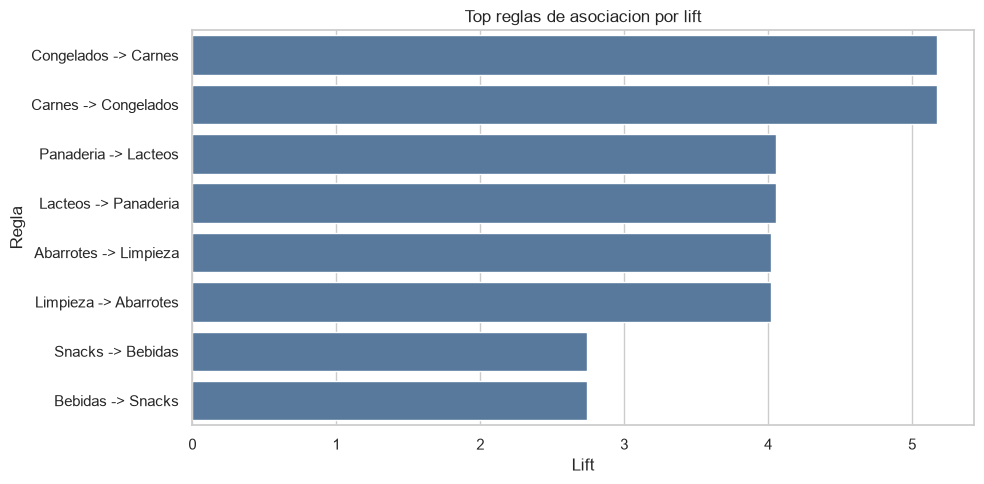

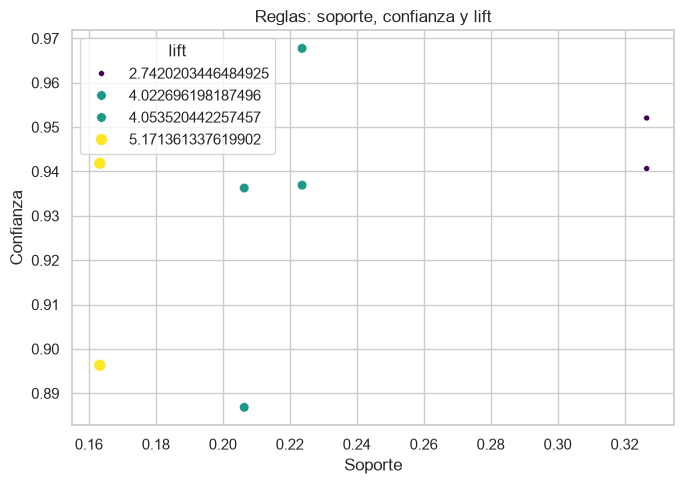

In [6]:
top_reglas = reglas[columnas_reglas].head(10).copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_reglas, x='lift', y='regla', ax=ax, color='#4C78A8')
ax.set_title('Top reglas de asociacion por lift')
ax.set_xlabel('Lift')
ax.set_ylabel('Regla')
fig.tight_layout()
fig.savefig(IMG / 'asociacion_top_reglas_lift.png', dpi=140)

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=reglas, x='support', y='confidence', size='lift', hue='lift', palette='viridis', ax=ax)
ax.set_title('Reglas: soporte, confianza y lift')
ax.set_xlabel('Soporte')
ax.set_ylabel('Confianza')
fig.tight_layout()
fig.savefig(IMG / 'asociacion_soporte_confianza_lift.png', dpi=140)

## 6. Acciones de negocio

Las reglas se traducen a propuestas comerciales: promociones cruzadas, bundles, ubicacion conjunta y recomendaciones en canal online.

In [7]:
def propuesta(row):
    return (
        f"Promocionar {row['consecuente']} a clientes que compran {row['antecedente']}; "
        "usar exhibicion conjunta, cupon cruzado o recomendacion online."
    )

reglas_export = reglas[columnas_reglas].copy()
reglas_export['propuesta_negocio'] = reglas_export.apply(propuesta, axis=1)
reglas_export['prioridad'] = pd.cut(
    reglas_export['lift'],
    bins=[0, 2, 4, 10],
    labels=['Media', 'Alta', 'Muy alta'],
)

reglas_export.head(10)

,regla,antecedente,consecuente,support,confidence,lift,propuesta_negocio,prioridad
7,Congelados -> Carnes,Congelados,Carnes,0.163245,0.941850,5.171361,Promocionar Carnes a clientes que compran Cong...,Muy alta
6,Carnes -> Congelados,Carnes,Congelados,0.163245,0.896318,5.171361,Promocionar Congelados a clientes que compran ...,Muy alta
3,Panaderia -> Lacteos,Panaderia,Lacteos,0.223679,0.967742,4.053520,Promocionar Lacteos a clientes que compran Pan...,Muy alta
2,Lacteos -> Panaderia,Lacteos,Panaderia,0.223679,0.936911,4.053520,Promocionar Panaderia a clientes que compran L...,Muy alta
5,Abarrotes -> Limpieza,Abarrotes,Limpieza,0.206407,0.936268,4.022696,Promocionar Limpieza a clientes que compran Ab...,Muy alta
4,Limpieza -> Abarrotes,Limpieza,Abarrotes,0.206407,0.886832,4.022696,Promocionar Abarrotes a clientes que compran L...,Muy alta
0,Snacks -> Bebidas,Snacks,Bebidas,0.326602,0.952053,2.742020,Promocionar Bebidas a clientes que compran Sna...,Alta
1,Bebidas -> Snacks,Bebidas,Snacks,0.326602,0.940650,2.742020,Promocionar Snacks a clientes que compran Bebi...,Alta


## 7. Exportacion para Power BI e informe

In [8]:
itemsets_export = itemsets[['itemsets_txt', 'n_items', 'support']].copy()
itemsets_export = itemsets_export.rename(columns={'itemsets_txt': 'itemset'})

reglas_export.to_csv(DATA / 'reglas_asociacion.csv', sep=';', index=False, encoding='utf-8')
itemsets_export.to_csv(DATA / 'itemsets_frecuentes.csv', sep=';', index=False, encoding='utf-8')
resumen_transacciones.to_csv(DATA / 'resumen_transacciones_asociacion.csv', sep=';', index=False, encoding='utf-8')

md = '# Resumen de asociacion - canasta de mercado\n\n'
md += f"- Boletas analizadas: {len(transacciones):,}.\n"
md += f"- Boletas con al menos dos categorias: {len(transacciones_validas):,}.\n"
md += '- Metodo: Apriori sobre categorias compradas por boleta.\n'
md += '- Criterio de relevancia: reglas con lift > 1.\n\n'
md += '## Reglas principales\n\n'
for _, row in reglas_export.head(6).iterrows():
    md += f"- **{row['regla']}**: soporte {row['support']:.3f}, confianza {row['confidence']:.3f}, lift {row['lift']:.2f}. {row['propuesta_negocio']}\n"

(ROOT / 'informe' / 'resumen_asociacion.md').write_text(md, encoding='utf-8')
reglas_export.head(10)

,regla,antecedente,consecuente,support,confidence,lift,propuesta_negocio,prioridad
7,Congelados -> Carnes,Congelados,Carnes,0.163245,0.941850,5.171361,Promocionar Carnes a clientes que compran Cong...,Muy alta
6,Carnes -> Congelados,Carnes,Congelados,0.163245,0.896318,5.171361,Promocionar Congelados a clientes que compran ...,Muy alta
3,Panaderia -> Lacteos,Panaderia,Lacteos,0.223679,0.967742,4.053520,Promocionar Lacteos a clientes que compran Pan...,Muy alta
2,Lacteos -> Panaderia,Lacteos,Panaderia,0.223679,0.936911,4.053520,Promocionar Panaderia a clientes que compran L...,Muy alta
5,Abarrotes -> Limpieza,Abarrotes,Limpieza,0.206407,0.936268,4.022696,Promocionar Limpieza a clientes que compran Ab...,Muy alta
4,Limpieza -> Abarrotes,Limpieza,Abarrotes,0.206407,0.886832,4.022696,Promocionar Abarrotes a clientes que compran L...,Muy alta
0,Snacks -> Bebidas,Snacks,Bebidas,0.326602,0.952053,2.742020,Promocionar Bebidas a clientes que compran Sna...,Alta
1,Bebidas -> Snacks,Bebidas,Snacks,0.326602,0.940650,2.742020,Promocionar Snacks a clientes que compran Bebi...,Alta


## 8. Salidas generadas

- `data/processed/reglas_asociacion.csv`: reglas priorizadas para Power BI.
- `data/processed/itemsets_frecuentes.csv`: itemsets frecuentes.
- `data/processed/resumen_transacciones_asociacion.csv`: resumen de boletas analizadas.
- `informe/resumen_asociacion.md`: interpretacion y propuestas.
- Imagenes en `informe/img/`: reglas por lift y dispersion soporte-confianza-lift.